Develop code for a function that achieves the following:
- Input the number of electrodes you are using
- Input electrode correlations between electrode and Cz (reference), e.g., 5 electrodes that are 0.8 correlated, 4 that are 0.2 correlated, etc.
- Code calculates PSD for each electrode and then averages PSDs together to return 1 average PSD for all chosen electrodes
- This would be for multiple

In [1]:
def simulate_group_average_psd(n_ppts, corr_structure, base_seed=256, n_seconds=10, s_rate=250):
    import numpy as np
    from neurodsp.spectral import compute_spectrum_welch
    from simulate_cz_signal import generate_cz_signal

    group_psds = []

    for p in range(n_ppts):

        # Different seed per participant
        seed = base_seed + p
        np.random.seed(seed)

        # Generate Cz signal
        cz_signal = generate_cz_signal(seed=seed, n_seconds=n_seconds, s_rate=s_rate)

        sigma_source = np.std(cz_signal)

        psds = []

        # Loop through correlation structure
        for rho, n_elecs in corr_structure.items():

            for _ in range(n_elecs):

                noise_std = np.sqrt((1 - rho**2) / rho**2) * sigma_source
                noise = noise_std * np.random.randn(len(cz_signal))

                signal = rho * cz_signal + noise

                freqs, powers = compute_spectrum_welch(signal, fs=s_rate)
                psds.append(powers)

        # Average electrodes → one PSD per participant
        avg_psd = np.mean(psds, axis=0)

        # Store participant PSD
        group_psds.append(avg_psd)

    group_psds = np.array(group_psds)

    print(f"Simulated {n_ppts} participants")
    print(f"Output shape: {group_psds.shape}")

    return freqs, group_psds

In [7]:
# Simulating 10 ppts, averaging over 8 electrodes
corr_structure = {
    0.6: 5,
    0.4: 3}

freqs, group_psds = simulate_group_average_psd(n_ppts=10, corr_structure=corr_structure)

Simulated 10 participants
Output shape: (10, 126)


In [3]:
from neurodsp.plts import plot_power_spectra

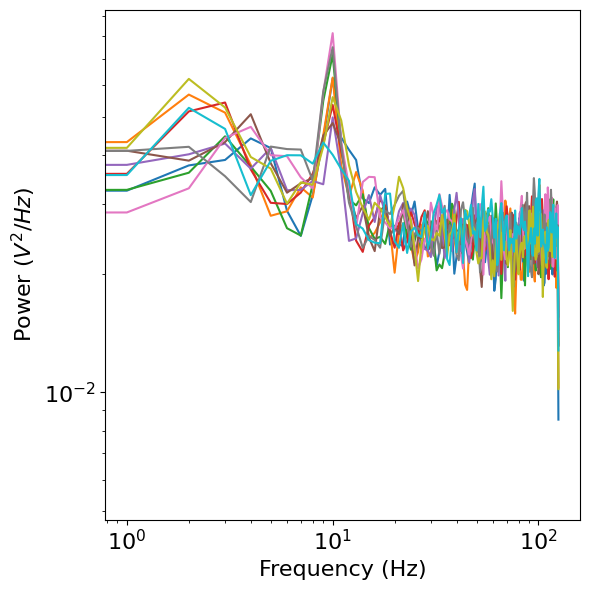

In [4]:
plot_power_spectra(freqs, group_psds)

In [5]:
from specparam import SpectralGroupModel
from specparam.sim import sim_group_power_spectra

C:\Users\chloe\OneDrive\Documents\Anaconda\envs\diss_worksheet\Lib\site-packages\specparam\data\data.py:292: RuntimeWarning: specparam fit warning - skipping frequency == 0, as this causes a problem with fitting.
  warn(msg, category=RuntimeWarning)



	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.

Fitting model across 10 power spectra.
                                                                                                  
                            GROUP SPECTRAL MODEL RESULTS (10 spectra)                             
                                                                                                  
                       The model was fit with the 'spectral_fit' algorithm                        
              Model was fit to the 1-125 Hz frequency range with 1.00 Hz resolution               
                                                                                                  
                               Aperiodic Parameters ('fixed' mode)                                
          

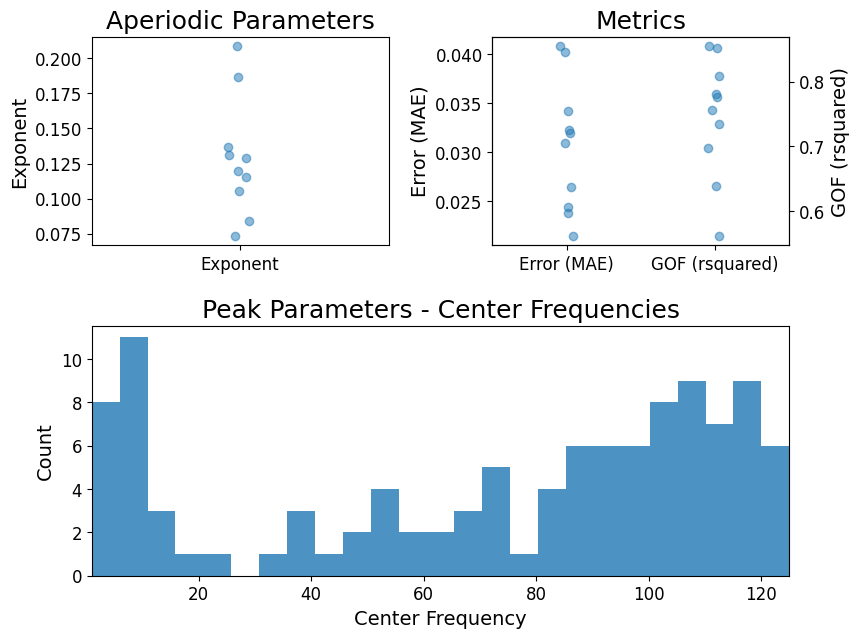

In [6]:
fg = SpectralGroupModel() 
fg.fit(freqs, group_psds) 
fg.print_results() 
fg.plot()

In [8]:
# Simulating 10 ppta, averaging over 61 electrodes
corr_structure = {
    1.0: 1,
    0.8: 8,
    0.6: 16,
    0.4: 16,
    0.2: 20}

freqs, group_psds = simulate_group_average_psd(n_ppts=10, corr_structure=corr_structure)

Simulated 10 participants
Output shape: (10, 126)


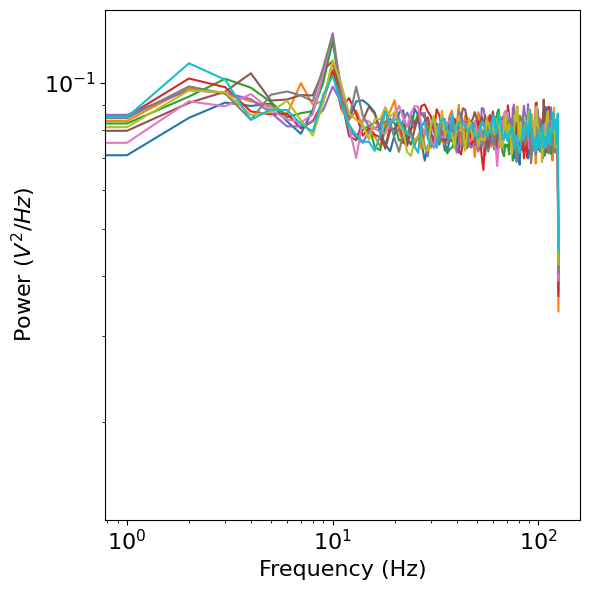

In [9]:
plot_power_spectra(freqs, group_psds)

C:\Users\chloe\OneDrive\Documents\Anaconda\envs\diss_worksheet\Lib\site-packages\specparam\data\data.py:292: RuntimeWarning: specparam fit warning - skipping frequency == 0, as this causes a problem with fitting.
  warn(msg, category=RuntimeWarning)



	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.

Fitting model across 10 power spectra.
                                                                                                  
                            GROUP SPECTRAL MODEL RESULTS (10 spectra)                             
                                                                                                  
                       The model was fit with the 'spectral_fit' algorithm                        
              Model was fit to the 1-125 Hz frequency range with 1.00 Hz resolution               
                                                                                                  
                               Aperiodic Parameters ('fixed' mode)                                
          

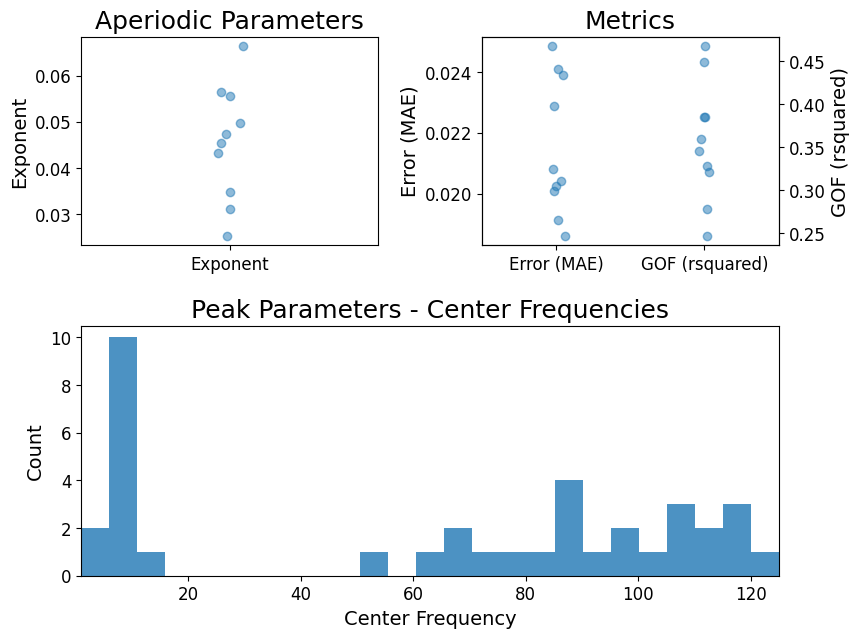

In [10]:
fg = SpectralGroupModel() 
fg.fit(freqs, group_psds) 
fg.print_results() 
fg.plot()